#Customer Segmentation Engine

Build a tool that segments customers based on purchase history (annual income, spending score,
etc.). Use K-Means from scikit-learn. Output 3-5 customer segments with visualizations and
descriptions of each segment.


#Import the necessary libraries

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.cluster import KMeans
%matplotlib inline

Upload our dataset

In [4]:
df= pd.read_csv('/content/Mall_Customers.csv')

#Conduct some EDA to better understand our dataset

In [5]:
df.head()


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [7]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [9]:
df.isna().sum()


,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [10]:
df.duplicated().sum()
#to check for any duplicate records and drop them

np.int64(0)

If the mall wants to understand their customer segment better , they need to analyze shopping habits and divide the customers into segments.

Since our dataset does not have predefined labels, this is a *clustering problem*.

To divide the dataset into workable customer segments eg. high-income repeat shoppers, we will use the KMeans supervised learning algorithm to identify these segments by minimizing the distance between data points and their respective cluster centers.

Our analysis will focus on key behavioral and demographic features, that is:

Annual Income (k$): The yearly earnings of the customer.

Spending Score (1-100): A score assigned by the mall based on customer behavior and purchasing patterns.

Age and Gender: Demographic factors that help refine the persona of each segment.

In [11]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [12]:
#split the customers based on gender
#our output shows the %division of male vs female customers

df['Genre'].value_counts(normalize=True) * 100

,proportion
Genre,
Female,56.0
Male,44.0


In [13]:
df['Genre'].value_counts()
#this shows the actual count

,count
Genre,
Female,112
Male,88


In [14]:
#we do the same for age
df['Age'].describe()


,Age
count,200.000000
mean,38.850000
std,13.969007
min,18.000000
25%,28.750000
50%,36.000000
75%,49.000000
max,70.000000


In [15]:
#we do the same for annual income
df['Annual Income (k$)'].describe()


,Annual Income (k$)
count,200.000000
mean,60.560000
std,26.264721
min,15.000000
25%,41.500000
50%,61.500000
75%,78.000000
max,137.000000


In [16]:
#we do the same for the spending score
df['Spending Score (1-100)'].describe()


,Spending Score (1-100)
count,200.000000
mean,50.200000
std,25.823522
min,1.000000
25%,34.750000
50%,50.000000
75%,73.000000
max,99.000000


#We will now apply a split-apply-combine" strategy to group the various columns

In [17]:
#age and gender
df.groupby('Genre')['Age'].mean()

,Age
Genre,
Female,38.098214
Male,39.806818


In [19]:
#gender and spending score
df.groupby('Genre')['Spending Score (1-100)'].mean()


,Spending Score (1-100)
Genre,
Female,51.526786
Male,48.511364


In [20]:
#gender and annual income
df.groupby('Genre')['Annual Income (k$)'].mean()


,Annual Income (k$)
Genre,
Female,59.250000
Male,62.227273


In [21]:
#age and annual income
df.groupby('Age')['Annual Income (k$)'].mean()


,Annual Income (k$)
Age,
18,51.250000
19,57.000000
20,41.600000
21,38.800000
22,31.333333
23,41.500000
24,39.250000
25,57.666667
26,58.000000


In [22]:
#age and spending score
df.groupby('Age')['Spending Score (1-100)'].mean()


,Spending Score (1-100)
Age,
18,60.000000
19,39.750000
20,40.200000
21,66.800000
22,70.000000
23,63.333333
24,71.500000
25,39.666667
26,54.500000


In [23]:
"""To determine the number of bins we will need for our
    age distribution plot, we will count the instances of unique
    values under the age column"""

df['Age'].nunique()


51

#Census of the data set
K-Means works by calculating distances. If the data in our data set is heavily skewed (e.g., everyone is exactly 20 years old except for one 90-year-old), that one outlier will ruin the clusters.

These plots will help confirm the data is "clean" and spread out enough to be grouped.

Now we make a plot to understand the age distribution of customers.

<function matplotlib.pyplot.show(close=None, block=None)>

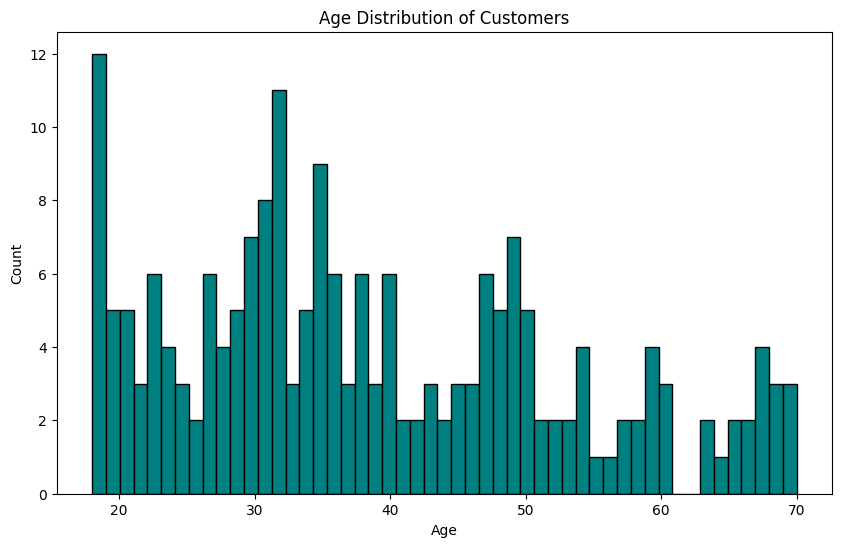

In [24]:
plt.figure(figsize=(10,6))
plt.hist(df['Age'], bins=51, color='teal', edgecolor='black')
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show

Now we make a plot to understand the income distribution of customers.

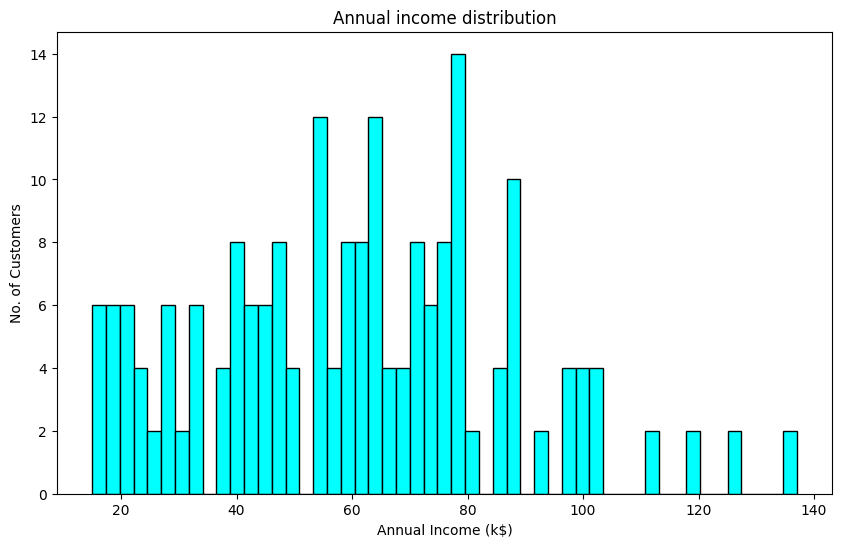

In [25]:
plt.figure(figsize=(10,6))
plt.hist(df['Annual Income (k$)'], bins=51, color='cyan', edgecolor='black')
plt.title('Annual income distribution')
plt.xlabel('Annual Income (k$)')
plt.ylabel('No. of Customers')
plt.show()

Now we make a plot to understand the income distribution of customers spending scores.

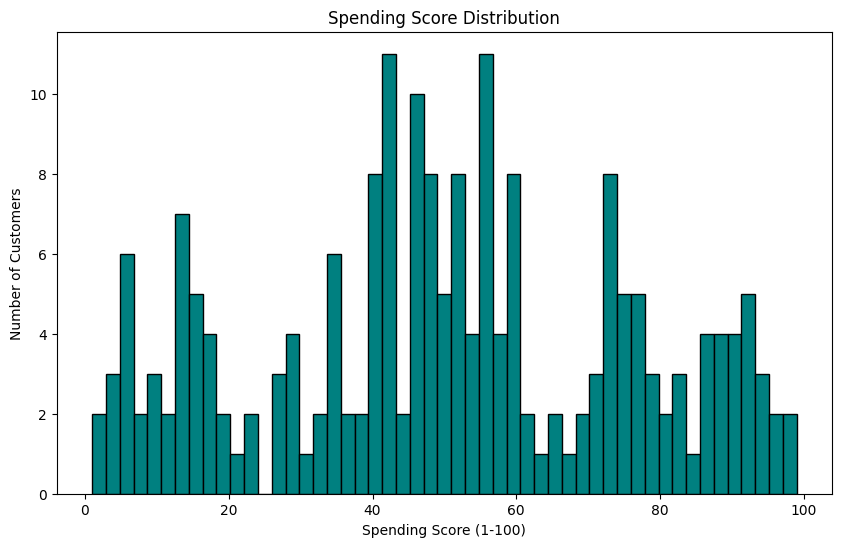

In [26]:
plt.figure(figsize=(10,6))
plt.hist(df['Spending Score (1-100)'], bins=51, color='teal', edgecolor='black')
plt.title('Spending Score Distribution')
plt.xlabel('Spending Score (1-100)')
plt.ylabel('Number of Customers')
plt.show()

#Scatter Plot: Annual Income vs Spending Score

This scatter plot is used to visualize the relationship between customers’ annual income and spending score. It helps us to identify natural groupings of customers.

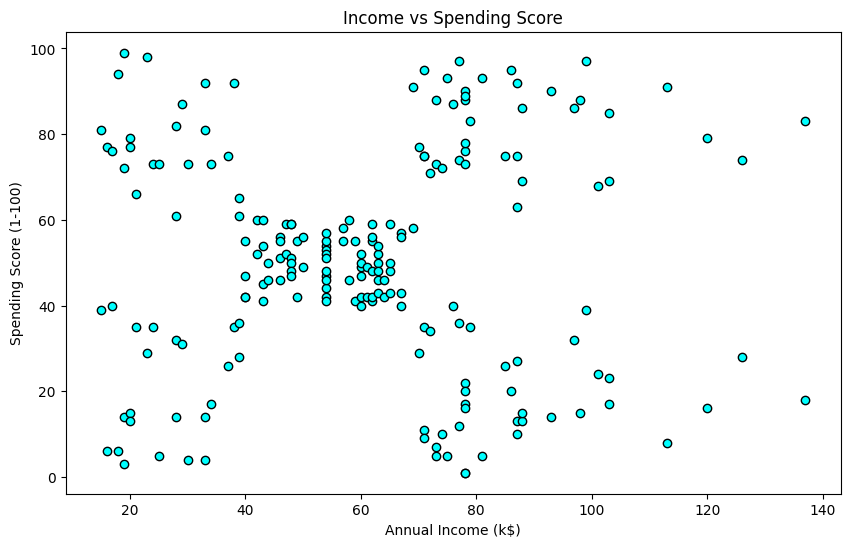

In [27]:
plt.figure(figsize=(10,6))
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c='cyan', edgecolor='k')
plt.title('Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

#Annual Income by Gender

This plot will help us compare income distribution across gender groups.

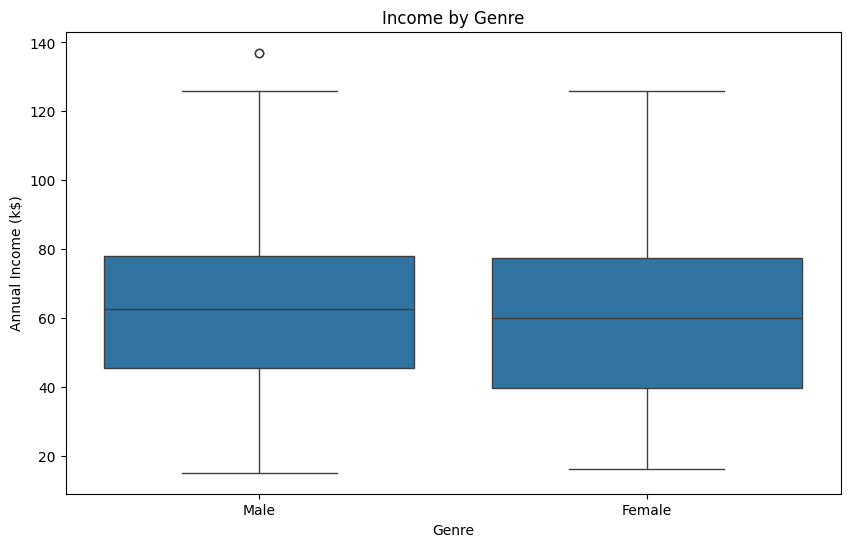

In [28]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='Genre', y='Annual Income (k$)')
plt.title('Income by Genre')
plt.show()

#Spending Score by Gender

Here ,we compare how spending behavior differs across gender.This is important because Spending Score is one of the key clustering variables.

So before clustering, we want to know:

whether one gender tends to spend more
whether spending is evenly distributed

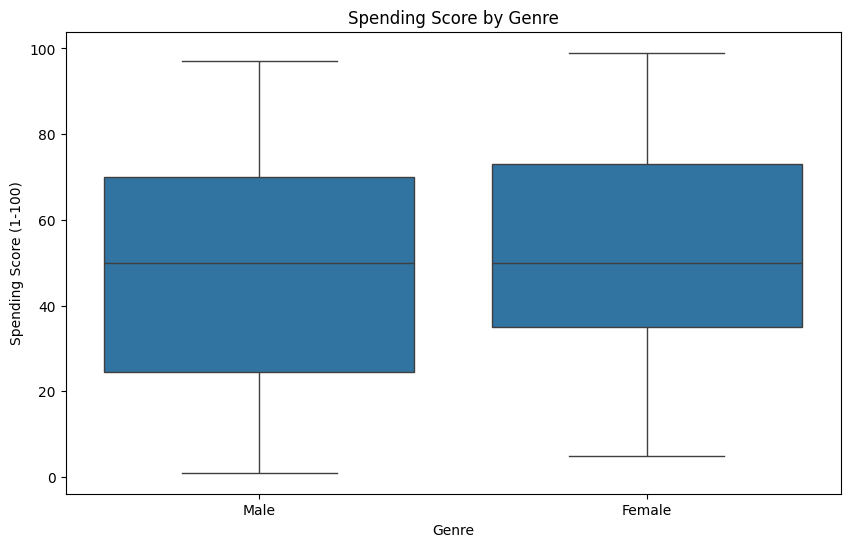

In [29]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Genre', y='Spending Score (1-100)')
plt.title('Spending Score by Genre')
plt.show()


#Age vs Spending Score

Age can help us explain customer personas, such as:

young impulsive spenders
older cautious spenders
middle-aged moderate spenders

Even if our final K-Means uses income + spending, age is very useful for interpreting the clusters.

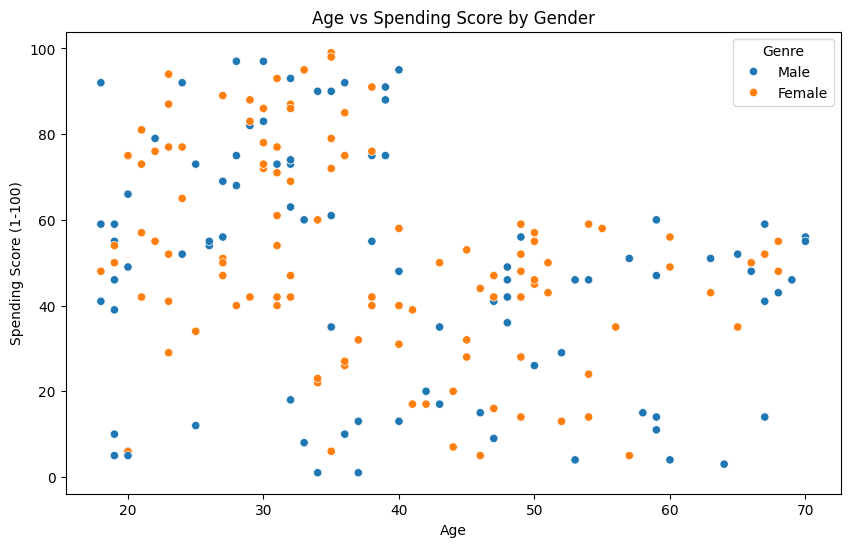

In [33]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Age', y='Spending Score (1-100)', hue='Genre')
plt.title('Age vs Spending Score by Gender')
plt.show()


Age vs Annual Income

This plot will help us see whether income changes with age.
This is useful for customer profiling.

For example:

a cluster may be older high-income low-spending customers while
another may be younger medium-income high-spending customers

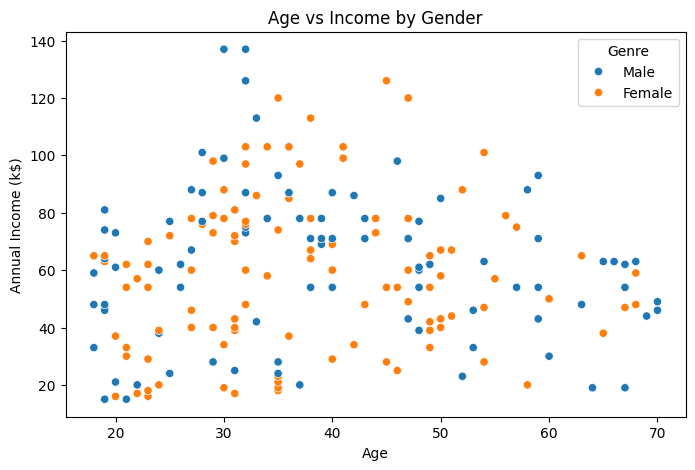

In [34]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Age', y='Annual Income (k$)', hue='Genre')
plt.title('Age vs Income by Gender')
plt.show()

We will use the *Annual Income *and *Spending score* as features(X) for clustering.

#THE ELBOW METHOD

In order to determine the correct number of K *centroids*, we will use the elbow method (check the elbow of a scatter plot)

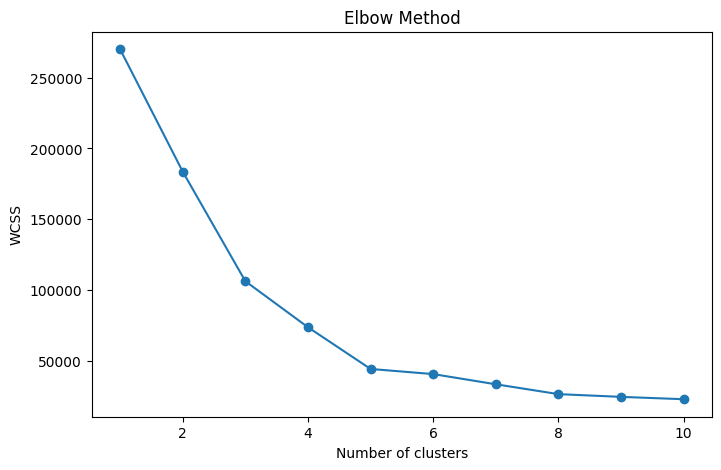

In [40]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

#we will use the sum of squared error(wcss) shown below:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

Accordinf to our plot, the "elbow" of the scatterplot of our features is approximately 5.

As a result, we take our K to be = 5

#Now we group our data into clusters.

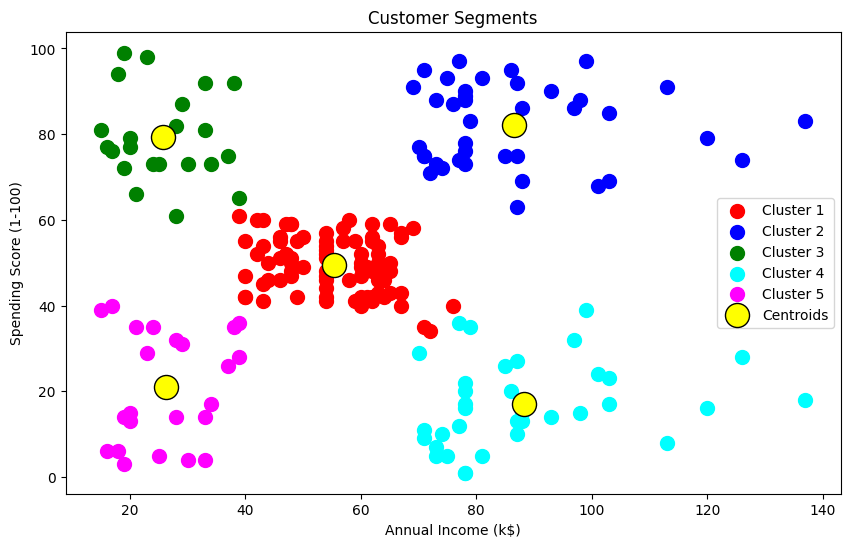

In [38]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X)

plt.figure(figsize=(10,6))
plt.scatter(X.iloc[y_kmeans==0, 0], X.iloc[y_kmeans==0, 1], s=100, c='red', label='Cluster 1')
plt.scatter(X.iloc[y_kmeans==1, 0], X.iloc[y_kmeans==1, 1], s=100, c='blue', label='Cluster 2')
plt.scatter(X.iloc[y_kmeans==2, 0], X.iloc[y_kmeans==2, 1], s=100, c='green', label='Cluster 3')
plt.scatter(X.iloc[y_kmeans==3, 0], X.iloc[y_kmeans==3, 1], s=100, c='cyan', label='Cluster 4')
plt.scatter(X.iloc[y_kmeans==4, 0], X.iloc[y_kmeans==4, 1], s=100, c='magenta', label='Cluster 5')

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=300, c='yellow', edgecolor='black', label='Centroids')

plt.title('Customer Segments')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

#RESULTS INTERPRATATION:

Our model has yielded 5 total customer segments, each differentiated in different colours.
The big yellow dots indicate the 5 centroids for each group.

The clusters can be interprated as follows:

**Cluster One(Red)**
 The average most common consumer.Average income and spend.

 **Cluster Two(Blue)**
 The most valuable segment, this category is the high spending/High Income band.

 **Cluster Three(Green)**
 Is the low income, high spend cluster.

**Cluster Four(Teal)**
The high income low spend band

**Cluster Five(piNK)**

The low income-low spend score category of consumers.

#Let's experiment with other plots to see the segments a bit to see the clusters better:

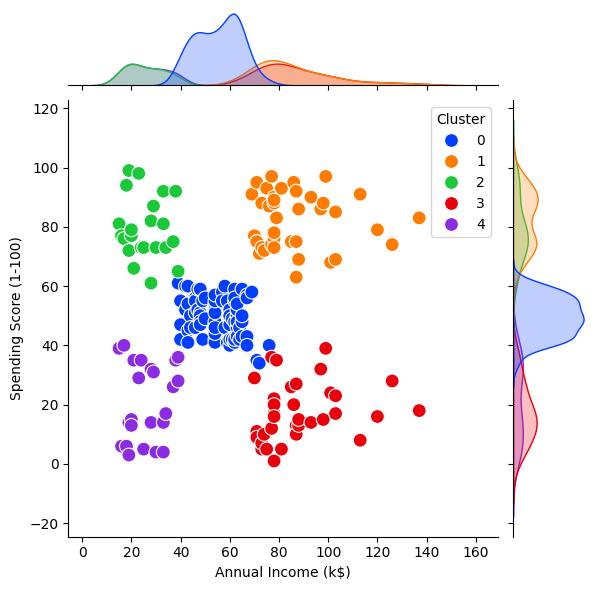

In [41]:
X_with_clusters = X.copy()
X_with_clusters['Cluster'] = y_kmeans
# creates a scatter plot with density "shadows" and histograms on the sides
sns.jointplot(x='Annual Income (k$)', y='Spending Score (1-100)',
              data=X_with_clusters, hue='Cluster', palette='bright', s=100)
plt.show()

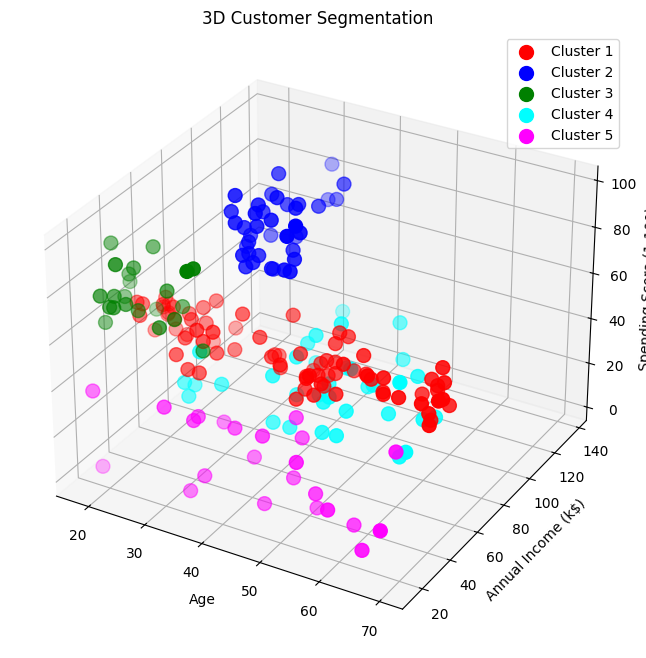

In [43]:
from mpl_toolkits.mplot3d import Axes3D

# Visualize the 2D clusters (based on Annual Income and Spending Score) in 3D, adding Age as a third dimension
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the clusters
colors = ['red', 'blue', 'green', 'cyan', 'magenta']
for i in range(5):
    ax.scatter(df.loc[y_kmeans == i, 'Age'], X.iloc[y_kmeans == i, 0], X.iloc[y_kmeans == i, 1],
               s=100, c=colors[i], label=f'Cluster {i+1}')

ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score (1-100)')
plt.title('3D Customer Segmentation')
plt.legend()
plt.show()